# EXPERIMENT-4: Text Mining and Accessing Text Corpus

**Title:** Do text mining on extracted data and access a text corpus

### Objectives
1. Calculate the word count of a document.
2. Find the top 10 most frequent words and their frequencies.
3. Visualize word frequencies using a bar graph.
4. Generate and display a word cloud.
5. Study and implement Named Entity Recognition (NER).

**Libraries used:** NLTK, spaCy, pandas, matplotlib, WordCloud

In [1]:
# Install required libraries (run this cell once if needed)
!pip install -q nltk spacy wordcloud matplotlib pandas
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
# Import required libraries
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Libraries imported successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Libraries imported successfully.


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Part 1: Text Mining

We use the following sample document. You can replace it with text extracted from a `.txt` file, PDF, webpage, or dataset.

In [9]:
# Sample document
text = """
Artificial Intelligence and Natural Language Processing are important areas of computer science.
Natural Language Processing enables computers to understand human language.
Machine learning and deep learning are widely used in Natural Language Processing.
Text mining helps researchers discover useful information from large collections of documents.
Python provides powerful libraries for text mining, including NLTK, spaCy, pandas, and scikit-learn.
Natural Language Processing applications include chatbots, sentiment analysis, machine translation,
text classification, information extraction, and named entity recognition.
"""

print("Document:")
print(text)

Document:

Artificial Intelligence and Natural Language Processing are important areas of computer science.
Natural Language Processing enables computers to understand human language.
Machine learning and deep learning are widely used in Natural Language Processing.
Text mining helps researchers discover useful information from large collections of documents.
Python provides powerful libraries for text mining, including NLTK, spaCy, pandas, and scikit-learn.
Natural Language Processing applications include chatbots, sentiment analysis, machine translation,
text classification, information extraction, and named entity recognition.



In [10]:
# Basic text preprocessing
# Convert to lowercase and keep alphabetic words
clean_text = re.sub(r'[^a-zA-Z\\s]', ' ', text.lower())

# Tokenize
tokens = word_tokenize(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens if word not in stop_words and len(word) > 1]

print("Total tokens:", len(tokens))
print("Words after stop-word removal:", len(filtered_words))
print("\nFirst 30 processed words:")
print(filtered_words[:30])

Total tokens: 77
Words after stop-word removal: 65

First 30 processed words:
['artificial', 'intelligence', 'natural', 'language', 'processing', 'important', 'areas', 'computer', 'science', 'natural', 'language', 'processing', 'enables', 'computers', 'understand', 'human', 'language', 'machine', 'learning', 'deep', 'learning', 'widely', 'used', 'natural', 'language', 'processing', 'text', 'mining', 'helps', 'researchers']


In [21]:
a = (1,2,3,4)
len(a)

4

In [11]:
# Calculate word count
word_count = len(filtered_words)

print(f"Total word count after preprocessing: {word_count}")

Total word count after preprocessing: 65


'ape'

In [12]:
# Calculate word frequencies
word_frequency = Counter(filtered_words)

# Top 10 frequent words
top_10 = word_frequency.most_common(10)

frequency_df = pd.DataFrame(top_10, columns=['Word', 'Frequency'])

print("Top 10 frequent words:")
display(frequency_df)

Top 10 frequent words:


,Word,Frequency
0,language,5
1,natural,4
2,processing,4
3,text,3
4,machine,2
5,learning,2
6,mining,2
7,information,2
8,artificial,1
9,intelligence,1


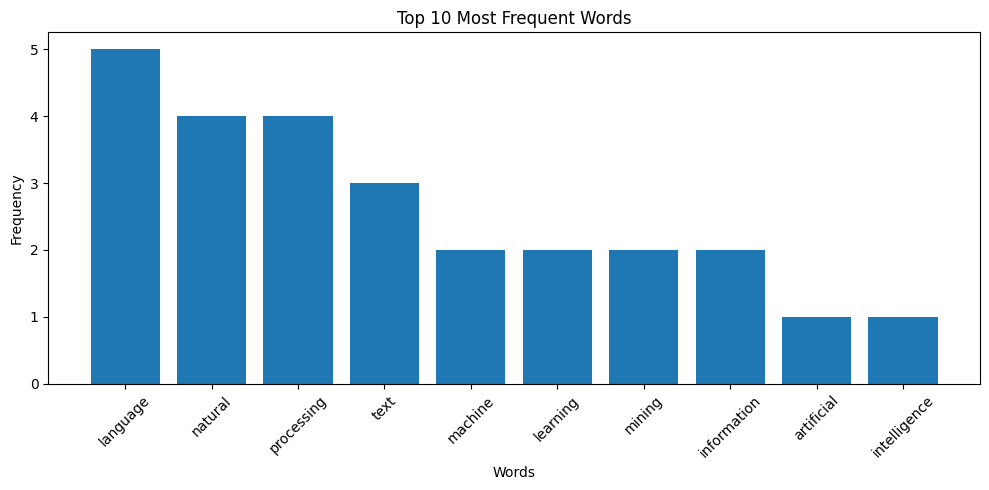

In [13]:
# Plot top 10 frequent words
plt.figure(figsize=(10, 5))
plt.bar(frequency_df['Word'], frequency_df['Frequency'])
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

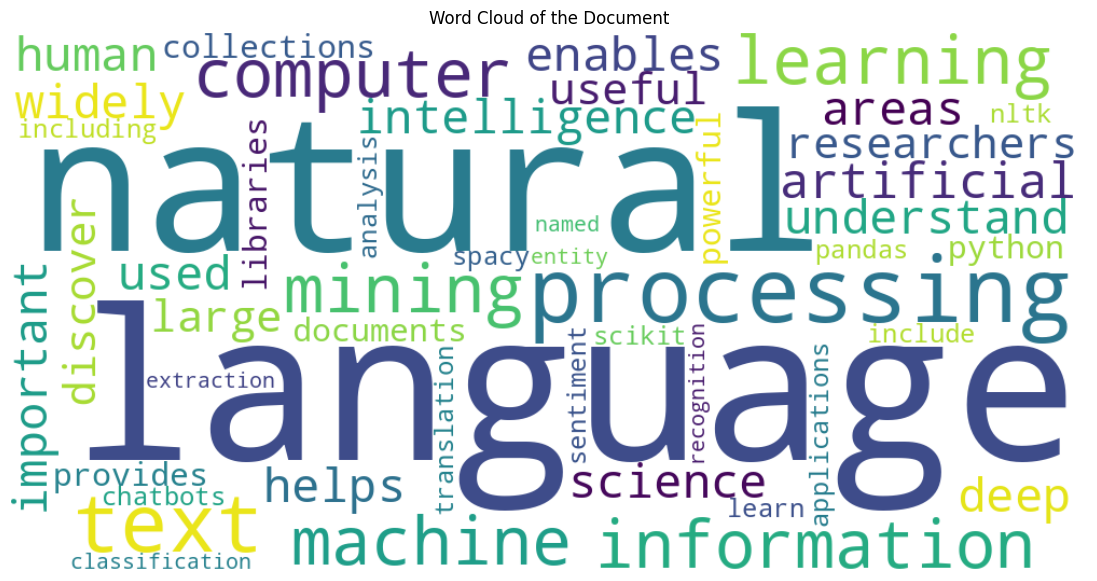

In [14]:
# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words,
    min_font_size=10
).generate(' '.join(filtered_words))

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of the Document')
plt.show()

## Part 2: Accessing a Text Corpus

NLTK provides several standard text corpora. The Brown Corpus is a commonly used corpus containing text from multiple categories.

The following example downloads and accesses the Brown Corpus.

In [15]:
# Download and access the Brown Corpus
nltk.download('brown')
from nltk.corpus import brown

print("Number of words in Brown Corpus:", len(brown.words()))
print("Number of sentences:", len(brown.sents()))
print("Number of categories:", len(brown.categories()))

print("\nCategories:")
print(brown.categories())

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Number of words in Brown Corpus: 1161192
Number of sentences: 57340
Number of categories: 15

Categories:
['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']


In [16]:
# Display sample words and sentences from the corpus
print("First 30 words:")
print(brown.words()[:30])

print("\nFirst sentence:")
print(' '.join(brown.sents()[0]))

First 30 words:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in']

First sentence:
The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .


## Part 3: Named Entity Recognition (NER)

**Named Entity Recognition** is an NLP technique used to identify entities such as:

- PERSON – names of people
- ORG – organizations
- GPE – countries, cities, states, etc.
- DATE – dates
- MONEY – monetary values
- LOC – locations

We use **spaCy** for NER.

In [17]:
# Load spaCy and its English language model
import spacy

nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded successfully.")

spaCy model loaded successfully.


In [18]:
# Example text for NER
ner_text = """
Dr. Sushil Ghildiyal is working as an Assistant Professor at UPES in Uttarakhand, India.
He completed his PhD at IIT Ropar and works in Artificial Intelligence, Machine Learning,
Natural Language Processing, and Remote Sensing. UPES is located in Dehradun.
"""

doc = nlp(ner_text)

print("Named Entities:")
for ent in doc.ents:
    print(f"{ent.text:25} -> {ent.label_:10} -> {spacy.explain(ent.label_)}")

Named Entities:
Sushil Ghildiyal          -> PERSON     -> People, including fictional
UPES                      -> ORG        -> Companies, agencies, institutions, etc.
Uttarakhand               -> GPE        -> Countries, cities, states
India                     -> GPE        -> Countries, cities, states
PhD                       -> WORK_OF_ART -> Titles of books, songs, etc.
IIT Ropar                 -> FAC        -> Buildings, airports, highways, bridges, etc.
Artificial Intelligence   -> ORG        -> Companies, agencies, institutions, etc.
Machine Learning          -> PERSON     -> People, including fictional
Natural Language Processing -> WORK_OF_ART -> Titles of books, songs, etc.
Remote Sensing            -> PERSON     -> People, including fictional
UPES                      -> ORG        -> Companies, agencies, institutions, etc.
Dehradun                  -> GPE        -> Countries, cities, states


In [19]:
# Display NER results graphically
from spacy import displacy

displacy.render(doc, style="ent", jupyter=True)

In [20]:
# Store NER results in a DataFrame
entities = [(ent.text, ent.label_, spacy.explain(ent.label_)) for ent in doc.ents]

ner_df = pd.DataFrame(
    entities,
    columns=['Entity', 'Label', 'Description']
)

display(ner_df)

,Entity,Label,Description
0,Sushil Ghildiyal,PERSON,"People, including fictional"
1,UPES,ORG,"Companies, agencies, institutions, etc."
2,Uttarakhand,GPE,"Countries, cities, states"
3,India,GPE,"Countries, cities, states"
4,PhD,WORK_OF_ART,"Titles of books, songs, etc."
5,IIT Ropar,FAC,"Buildings, airports, highways, bridges, etc."
6,Artificial Intelligence,ORG,"Companies, agencies, institutions, etc."
7,Machine Learning,PERSON,"People, including fictional"
8,Natural Language Processing,WORK_OF_ART,"Titles of books, songs, etc."
9,Remote Sensing,PERSON,"People, including fictional"


## Result

The experiment demonstrates:

1. Text preprocessing and tokenization.
2. Word count calculation.
3. Identification of the top 10 frequent words.
4. Graphical visualization using a frequency bar chart.
5. Word cloud generation.
6. Accessing and exploring the NLTK Brown text corpus.
7. Named Entity Recognition using spaCy.
8. Visualization and tabular representation of recognized entities.

### Conclusion

Text mining techniques can be used to extract useful patterns and statistics from unstructured text. Frequency analysis and word clouds provide simple ways to understand the important terms in a document, while NER identifies meaningful entities such as people, organizations, locations, and dates from text.